# 02 Data Cleaning

Validacion de reglas de limpieza sobre muestra de `RAW` y contraste con `OBT`.

Objetivos:
- cuantificar el impacto de cada filtro
- revisar ejemplos invalidos
- justificar las reglas que viven en SQL


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import fetch_sample
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()
raw_sample = fetch_sample(f"SELECT * FROM {settings.raw_table}", limit=12000, settings=settings)
obt_sample = fetch_sample(f"SELECT * FROM {settings.obt_table}", limit=12000, settings=settings)
assert not raw_sample.empty, 'La muestra raw esta vacia.'
assert not obt_sample.empty, 'La muestra OBT esta vacia.'
print('raw sample =', raw_sample.shape)
print('obt sample =', obt_sample.shape)
raw_sample.head()


raw sample = (12000, 19)
obt sample = (12000, 12)


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2025-01-01 19:35:21,2025-01-01 19:48:25,1,2.62,1,N,237,238,1,15.6,2.5,0.5,4.42,0.0,1.0,26.52,2.5,0.0
1,2,2025-01-01 19:58:28,2025-01-01 20:21:24,2,4.76,1,N,79,43,1,25.4,0.0,0.5,5.88,0.0,1.0,35.28,2.5,0.0
2,2,2025-01-01 19:08:10,2025-01-01 19:29:55,1,3.03,1,N,211,230,1,20.5,0.0,0.5,4.90,0.0,1.0,29.40,2.5,0.0
3,1,2025-01-01 19:14:56,2025-01-01 19:26:22,1,2.20,1,N,263,233,1,12.1,2.5,0.5,2.00,0.0,1.0,18.10,2.5,0.0
4,2,2025-01-01 19:45:49,2025-01-01 19:55:31,1,0.95,1,N,246,48,1,10.0,2.5,0.5,3.30,0.0,1.0,19.80,2.5,0.0


In [3]:
raw_required = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
    'pulocationid', 'dolocationid', 'fare_amount'
]
missing_raw = sorted(set(raw_required).difference(raw_sample.columns))
assert not missing_raw, f'Faltan columnas esperadas en RAW: {missing_raw}'
raw_sample['trip_duration_min'] = (pd.to_datetime(raw_sample['tpep_dropoff_datetime']) - pd.to_datetime(raw_sample['tpep_pickup_datetime'])).dt.total_seconds() / 60
raw_sample[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_min"]].head()


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min
0,2025-01-01 19:35:21,2025-01-01 19:48:25,13.066667
1,2025-01-01 19:58:28,2025-01-01 20:21:24,22.933333
2,2025-01-01 19:08:10,2025-01-01 19:29:55,21.750000
3,2025-01-01 19:14:56,2025-01-01 19:26:22,11.433333
4,2025-01-01 19:45:49,2025-01-01 19:55:31,9.700000


In [4]:
pickup_dates = pd.to_datetime(raw_sample["tpep_pickup_datetime"], errors="coerce").dt.date
rule_table = pd.DataFrame({
    'rule': [
        'pickup not null', 'dropoff not null', 'pickup in configured range', 'dropoff after pickup',
        'trip_distance > 0', 'passenger_count between 1 and 6', 'fare_amount > 0',
        'pickup location not null', 'dropoff location not null'
    ],
    'rows_passing': [
        raw_sample['tpep_pickup_datetime'].notna().sum(),
        raw_sample['tpep_dropoff_datetime'].notna().sum(),
        pickup_dates.between(pd.to_datetime(settings.data_start_date).date(), pd.to_datetime(settings.data_end_date).date()).sum(),
        (raw_sample['trip_duration_min'] > 0).sum(),
        (raw_sample['trip_distance'] > 0).sum(),
        raw_sample['passenger_count'].between(1, 6).sum(),
        (raw_sample['fare_amount'] > 0).sum(),
        raw_sample['pulocationid'].notna().sum(),
        raw_sample['dolocationid'].notna().sum(),
    ],
})
rule_table['pass_pct'] = (rule_table['rows_passing'] / len(raw_sample) * 100).round(2)
rule_table


,rule,rows_passing,pass_pct
0,pickup not null,12000,100.00
1,dropoff not null,12000,100.00
2,pickup in configured range,12000,100.00
3,dropoff after pickup,11993,99.94
4,trip_distance > 0,11828,98.57
5,passenger_count between 1 and 6,11905,99.21
6,fare_amount > 0,11676,97.30
7,pickup location not null,12000,100.00
8,dropoff location not null,12000,100.00


In [5]:
invalid_examples = raw_sample.loc[
    ~(
        raw_sample["tpep_pickup_datetime"].notna()
        & raw_sample["tpep_dropoff_datetime"].notna()
        & (raw_sample["trip_duration_min"] > 0)
        & (raw_sample["trip_distance"] > 0)
        & raw_sample["passenger_count"].between(1, 6)
        & (raw_sample["fare_amount"] > 0)
        & raw_sample["pulocationid"].notna()
        & raw_sample["dolocationid"].notna()
    ),
    [
        "vendorid", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
        "trip_distance", "pulocationid", "dolocationid", "fare_amount", "trip_duration_min"
    ]
]
invalid_examples.head(15)


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,trip_duration_min
10,2,2025-01-01 19:18:00,2025-01-01 19:18:14,2,0.00,186,186,19.1,0.233333
13,1,2025-01-01 19:42:20,2025-01-01 20:11:27,0,3.60,144,48,27.5,29.116667
22,2,2025-01-01 19:26:38,2025-01-01 19:46:35,1,3.08,186,141,-20.5,19.950000
24,1,2025-01-01 19:45:29,2025-01-01 19:46:29,0,0.20,186,186,3.7,1.000000
75,2,2025-01-01 19:48:58,2025-01-01 20:06:32,2,0.00,161,42,14.9,17.566667
84,1,2025-01-01 19:50:21,2025-01-01 19:55:23,0,1.30,48,68,7.9,5.033333
119,2,2025-01-01 19:07:32,2025-01-01 19:26:51,1,0.70,230,100,-16.3,19.316667
138,2,2025-01-01 19:19:55,2025-01-01 19:22:25,1,0.56,137,107,-5.1,2.500000
183,2,2025-01-01 19:17:40,2025-01-01 19:40:52,2,0.98,161,100,-19.1,23.200000
194,1,2025-01-01 19:26:40,2025-01-01 20:00:46,0,12.00,138,144,51.3,34.100000


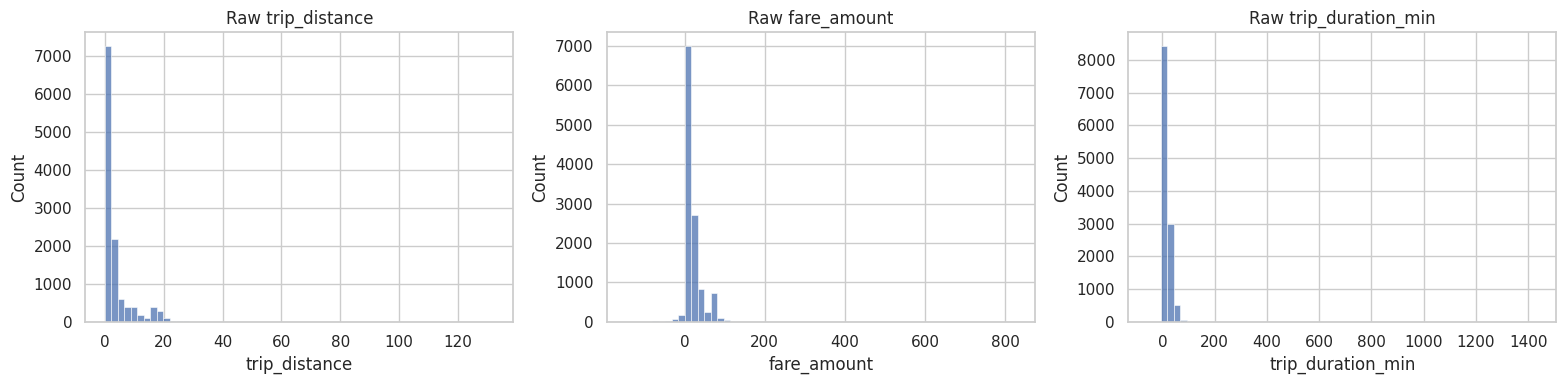

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw_sample['trip_distance'], bins=60, ax=axes[0])
axes[0].set_title('Raw trip_distance')
sns.histplot(raw_sample['fare_amount'], bins=60, ax=axes[1])
axes[1].set_title('Raw fare_amount')
sns.histplot(raw_sample['trip_duration_min'].dropna(), bins=60, ax=axes[2])
axes[2].set_title('Raw trip_duration_min')
plt.tight_layout()


In [7]:
raw_vs_obt = pd.DataFrame({
    'dataset': ['raw_sample', 'obt_sample'],
    'rows': [len(raw_sample), len(obt_sample)],
    'fare_amount_mean': [raw_sample['fare_amount'].mean(), obt_sample['fare_amount'].mean()],
    'trip_distance_mean': [raw_sample['trip_distance'].mean(), obt_sample['trip_distance'].mean()],
    'passenger_count_mean': [raw_sample['passenger_count'].mean(), obt_sample['passenger_count'].mean()],
})
raw_vs_obt


,dataset,rows,fare_amount_mean,trip_distance_mean,passenger_count_mean
0,raw_sample,12000,19.767217,3.781150,1.445333
1,obt_sample,12000,20.326467,3.730132,1.458833


In [8]:
sql_rules_final = pd.DataFrame({
    'sql_rule': [
        'tpep_pickup_datetime IS NOT NULL',
        'tpep_dropoff_datetime IS NOT NULL',
        'pickup date between configured start/end',
        'tpep_dropoff_datetime > tpep_pickup_datetime',
        'trip_distance > 0',
        'passenger_count BETWEEN 1 AND 6',
        'fare_amount > 0',
        'pulocationid IS NOT NULL',
        'dolocationid IS NOT NULL',
    ]
})
sql_rules_final


,sql_rule
0,tpep_pickup_datetime IS NOT NULL
1,tpep_dropoff_datetime IS NOT NULL
2,pickup date between configured start/end
3,tpep_dropoff_datetime > tpep_pickup_datetime
4,trip_distance > 0
5,passenger_count BETWEEN 1 AND 6
6,fare_amount > 0
7,pulocationid IS NOT NULL
8,dolocationid IS NOT NULL


## Conclusiones esperadas

- Las reglas estructurales deben vivir en SQL, no en pandas sobre toda la base.
- Este notebook justifica esas reglas con evidencia muestral.
